In [6]:
import numpy as np
import pandas as pd
#set seed for reproducubility
np.random.seed(42)
#genrate dates
date_range=pd.date_range(start='2024-01-01', end='2025-12-31')
#genrate random weather data
temperature=np.random.normal(loc=20, scale=10, size=len(date_range))
humidity=np.random.uniform(30,100,size=len(date_range))
precipitation=np.random.exponential(scale=3,size=len(date_range))
#introduce some missing values
temperature[np.random.choice(len(temperature),10,replace=False)]=np.nan
humidity[np.random.choice(len(humidity),10,replace=False)]=np.nan
precipitation[np.random.choice(len(precpitation),10,replace=False)]=np.nan


#create dataframe 
Weather_df=pd.DataFrame({
    'Date':date_range,
    'Temperature_c':np.round(temperature,1),
    'Humidity_%': np.round(humidity,1),
    'Precpitation_mm':np.round(precpitation,1)})
#save Csv
Weather_df.to_csv('weather_data.csv',index=False)

In [7]:
df=pd.read_csv('weather_data.csv')
df.head()

,Date,Temperature_c,Humidity_%,Precpitation_mm
0,2024-01-01,25.0,49.2,6.3
1,2024-01-02,NaN,68.8,6.1
2,2024-01-03,26.5,75.6,4.9
3,2024-01-04,35.2,88.1,4.7
4,2024-01-05,17.7,44.4,1.1


In [8]:
print(df.info())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             731 non-null    object 
 1   Temperature_c    721 non-null    float64
 2   Humidity_%       721 non-null    float64
 3   Precpitation_mm  731 non-null    float64
dtypes: float64(3), object(1)
memory usage: 23.0+ KB
None
       Temperature_c  Humidity_%  Precpitation_mm
count     721.000000  721.000000       731.000000
mean       19.806796   65.640222         2.924350
std         9.797636   20.450028         2.866707
min       -12.400000   30.300000         0.000000
25%        13.000000   47.200000         0.900000
50%        19.900000   66.800000         2.100000
75%        26.200000   82.900000         4.100000
max        58.500000  100.000000        19.200000
Index(['Date', 'Temperature_c', 'Humidity_%', 'Precpitation_mm'], dtype='object')


In [10]:
df=df.dropna()
df['Date']=pd.to_datetime(df['Date'])

In [15]:
temperature=df['Temperature_c'].values
humidity=df['Humidity_%'].values
precip=df['Precpitation_mm'].values
print('Temperature-mean:',np.mean(temperature), 'median:',np.median(temperature), 'Std:',np.std(temperature))
print('Humidity-mean:',np.mean(precip))
print('Precipitaion-std:',np.std(precip))

Temperature-mean: 19.79789621318373 median: 19.9 Std: 9.803048359816886
Humidity-mean: 2.9504908835904624
Precipitaion-std: 2.8783474513613547


In [17]:
df['Month']=df['Date'].dt.month
monthly_avg=df.groupby('Month')[['Temperature_c','Humidity_%','Precpitation_mm']].mean()
print(monthly_avg)

       Temperature_c  Humidity_%  Precpitation_mm
Month                                            
1          19.544262   65.070492         2.845902
2          20.130909   65.056364         3.307273
3          18.816129   68.119355         3.264516
4          19.618333   64.661667         2.735000
5          19.389655   66.817241         2.700000
6          19.448333   66.943333         3.528333
7          20.693443   67.331148         3.334426
8          20.178333   65.765000         3.096667
9          20.161017   65.505085         2.171186
10         20.136667   65.383333         2.933333
11         20.529825   64.077193         2.559649
12         19.006667   62.330000         2.903333


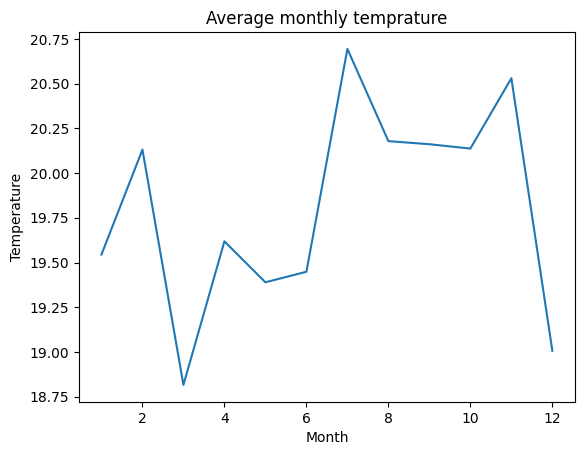

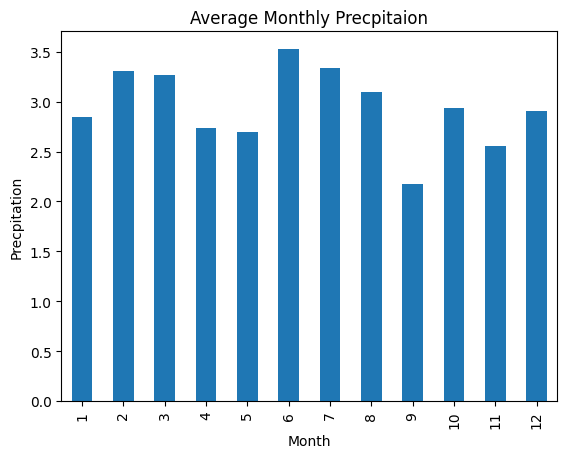

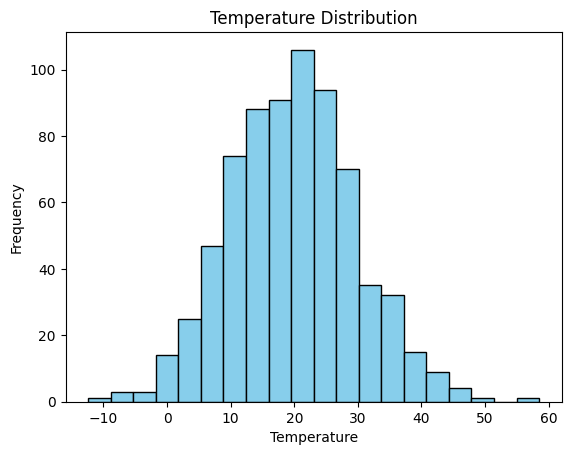

In [31]:
import matplotlib.pyplot as plt
monthly_avg['Temperature_c'].plot()
plt.title('Average monthly temprature')
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.show()

monthly_avg['Precpitation_mm'].plot(kind='bar', title='Average Monthly Precpitaion')
plt.xlabel('Month')
plt.ylabel('Precpitation')
plt.show()

plt.hist(df['Temperature_c'],bins=20 , edgecolor='black',color='skyblue')
plt.title('Temperature Distribution')
plt.xlabel('Temperature')

plt.ylabel('Frequency')
plt.show()
           

In [33]:
extreme_temp=df[np.abs(df['Temperature_c']-np.mean(df['Temperature_c']))>2* np.std(df['Temperature_c'])]
extreme_precp=df[df['Precpitation_mm']>df['Precpitation_mm'].quantile(.95)]
print("extreme temperature by day:")
print(extreme_temp)
print('extreme precpitaion by day')
print(extreme_precp)

extreme temperature by day:
          Date  Temperature_c  Humidity_%  Precpitation_mm  Month
74  2024-03-15           -6.2        79.4              2.0      3
79  2024-03-20            0.1        32.4              2.3      3
113 2024-04-23           44.6        85.9              3.2      4
125 2024-05-05           41.9        81.6              3.8      5
179 2024-06-28           47.2        39.1              1.0      6
209 2024-07-28           58.5        90.7              3.5      7
220 2024-08-08           43.1        87.8              1.5      8
234 2024-08-22           41.4        74.4              0.7      8
236 2024-08-24           -0.3        84.6              1.4      8
252 2024-09-09           41.2        54.2              1.3      9
262 2024-09-19          -12.4        31.5              2.8      9
284 2024-10-11           41.3        59.4              8.1     10
374 2025-01-09           41.5        61.7              3.8      1
378 2025-01-13           41.9        35.7       